In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle

pd.options.mode.chained_assignment = None

eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_fit/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [ ]:
def get_cdf(cell,n=0):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    print(N1[-1])
    df = data[data["Cycle number"]==N1[n]]
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    return df

In [ ]:
cell = 26
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
n = 1
df0 = data[data["Cycle number"]==N1[n]]
df0["Time [s]"] = df0["Time [s]"] - df0["Time [s]"].iloc[0]
cell = 28
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
n = 0
df5 = data[data["Cycle number"]==N1[n]]

In [ ]:
df0  = get_cdf(26,n=1)
df1  = get_cdf(28,n=1)
df2  = get_cdf(29,n=1)
df3  = get_cdf(31,n=1)
df4  = get_cdf(33,n=1)
df5  = get_cdf(35,n=1)

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df0["Time [s]"],df0["Voltage [V]"],color=colors[0],linewidth=1.5)
ax.plot(df1["Time [s]"],df1["Voltage [V]"],color=colors[1],linewidth=1.5)
ax.plot(df2["Time [s]"],df2["Voltage [V]"],color=colors[2],linewidth=1.5)
ax.plot(df3["Time [s]"],df3["Voltage [V]"],color=colors[3],linewidth=1.5)
ax.plot(df4["Time [s]"],df4["Voltage [V]"],color=colors[4],linewidth=1.5)
ax.plot(df5["Time [s]"],df5["Voltage [V]"],color=colors[5],linewidth=1.5)
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_xlabel("Time [s]")
ax.set_ylabel("Cycling Voltage [V]")
ax.set_title("Fresh Cell Voltage for Various Pressures")
fig.savefig(fig_DIR + "BOL_V_Pressure.png")

In [ ]:
df0  = get_cdf(26,n=75)
df1  = get_cdf(28,n=75)
df2  = get_cdf(29,n=75)
df3  = get_cdf(31,n=75)
df4  = get_cdf(33,n=75)
df5  = get_cdf(35,n=75)

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df0["Time [s]"],df0["Voltage [V]"],color=colors[0],linewidth=1.5)
ax.plot(df1["Time [s]"],df1["Voltage [V]"],color=colors[1],linewidth=1.5)
ax.plot(df2["Time [s]"],df2["Voltage [V]"],color=colors[2],linewidth=1.5)
ax.plot(df3["Time [s]"],df3["Voltage [V]"],color=colors[3],linewidth=1.5)
ax.plot(df4["Time [s]"],df4["Voltage [V]"],color=colors[4],linewidth=1.5)
ax.plot(df5["Time [s]"],df5["Voltage [V]"],color=colors[5],linewidth=1.5)
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_xlabel("Time [s]")
ax.set_ylabel("Cycling Voltage [V]")
ax.set_title("MOL (Cyc=75) Voltage for Various Pressures")
fig.savefig(fig_DIR + "MOL_V_Pressure.png")

In [ ]:
df0  = get_cdf(26,n=150)
df1  = get_cdf(28,n=150)
df2  = get_cdf(29,n=150)
df3  = get_cdf(31,n=150)
df4  = get_cdf(33,n=150)
df5  = get_cdf(35,n=150)

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df0["Time [s]"],df0["Voltage [V]"],color=colors[0],linewidth=1.5)
ax.plot(df1["Time [s]"],df1["Voltage [V]"],color=colors[1],linewidth=1.5)
ax.plot(df2["Time [s]"],df2["Voltage [V]"],color=colors[2],linewidth=1.5)
ax.plot(df3["Time [s]"],df3["Voltage [V]"],color=colors[3],linewidth=1.5)
ax.plot(df4["Time [s]"],df4["Voltage [V]"],color=colors[4],linewidth=1.5)
ax.plot(df5["Time [s]"],df5["Voltage [V]"],color=colors[5],linewidth=1.5)
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_xlabel("Time [s]")
ax.set_ylabel("Cycling Voltage [V]")
ax.set_title("MOL (Cyc=150) Voltage for Various Pressures")
fig.savefig(fig_DIR + "EOL_V_Pressure.png")

In [ ]:
n = 25
cell = 33
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
print(N1[-1])
df = data[data["Cycle number"]==N1[n]]
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0))[0]
idx = idxi1[0]
t_ch = t[:idx]
I_ch = I[:idx]
V_ch = V[:idx]
Q_ch = Cap[:idx]
t_dh = t[idx:]-t[idx]
I_dh = I[idx:]
V_dh = V[idx:]
Q_dh = Cap[idx:]
fig,ax = plt.subplots(1,1)
ax.plot(t,I)
ax.plot(t[idx],I[idx],'x')

In [ ]:
def get_chdh(cell,n=0):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    df = data[data["Cycle number"]==N1[n]]
    if n == 1 and cell == 31:
        df = df.drop(df.index[0])
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    return t_ch,I_ch,V_ch,Q_ch,t_dh,I_dh,V_dh,Q_dh

In [ ]:
cell = 31
n = 1
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
df = data[data["Cycle number"]==N1[n]]
if n == 1 and cell == 31:
    df = df.drop(df.index[0])
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
idx = idxi1[0]
t_ch = t[:idx-1]
I_ch = I[:idx-1]
V_ch = V[:idx-1]
Q_ch = Cap[:idx-1]
t_dh = t[idx+1:]-t[idx+1]
I_dh = I[idx+1:]
V_dh = V[idx+1:]
Q_dh = Cap[idx+1:]

In [ ]:
for n in [1,25,50,75,100,125,150]:
# for n in [1]:
    t_ch0,I_ch0,V_ch0,Q_ch0,t_dh0,I_dh0,V_dh0,Q_dh0  = get_chdh(26,n=n)
    t_ch1,I_ch1,V_ch1,Q_ch1,t_dh1,I_dh1,V_dh1,Q_dh1  = get_chdh(28,n=n)
    t_ch2,I_ch2,V_ch2,Q_ch2,t_dh2,I_dh2,V_dh2,Q_dh2  = get_chdh(29,n=n)
    t_ch3,I_ch3,V_ch3,Q_ch3,t_dh3,I_dh3,V_dh3,Q_dh3  = get_chdh(31,n=n)
    t_ch4,I_ch4,V_ch4,Q_ch4,t_dh4,I_dh4,V_dh4,Q_dh4  = get_chdh(33,n=n)
    t_ch5,I_ch5,V_ch5,Q_ch5,t_dh5,I_dh5,V_dh5,Q_dh5  = get_chdh(35,n=n)
    # cy = 1
    colors = ['blue','red','green','orange','magenta','cyan']
    fig, ax = plt.subplots(1,1,figsize=(5,4))
    ax.plot(Q_ch0,V_ch0,color=colors[0],linewidth=1.5)
    ax.plot(Q_ch1,V_ch1,color=colors[1],linewidth=1.5)
    ax.plot(Q_ch2,V_ch2,color=colors[2],linewidth=1.5)
    ax.plot(Q_ch3,V_ch3,color=colors[3],linewidth=1.5)
    ax.plot(Q_ch4,V_ch4,color=colors[4],linewidth=1.5)
    ax.plot(Q_ch5,V_ch5,color=colors[5],linewidth=1.5)
    ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','sim'])
    ax.set_xlim([0,5])
    ax.set_xlabel("Q [Ah]")
    ax.set_ylabel("Cycling Voltage [V]")
    ax.set_title(f"Voltage for Various Pressures: N={n}")
    fig.savefig(fig_DIR + f"Pressure_data_{n}_ch.png")

In [ ]:
for n in [1,25,50,75,100,125,150]:
# for n in [1]:
    t_ch0,I_ch0,V_ch0,Q_ch0,t_dh0,I_dh0,V_dh0,Q_dh0  = get_chdh(26,n=n)
    t_ch1,I_ch1,V_ch1,Q_ch1,t_dh1,I_dh1,V_dh1,Q_dh1  = get_chdh(28,n=n)
    t_ch2,I_ch2,V_ch2,Q_ch2,t_dh2,I_dh2,V_dh2,Q_dh2  = get_chdh(29,n=n)
    t_ch3,I_ch3,V_ch3,Q_ch3,t_dh3,I_dh3,V_dh3,Q_dh3  = get_chdh(31,n=n)
    t_ch4,I_ch4,V_ch4,Q_ch4,t_dh4,I_dh4,V_dh4,Q_dh4  = get_chdh(33,n=n)
    t_ch5,I_ch5,V_ch5,Q_ch5,t_dh5,I_dh5,V_dh5,Q_dh5  = get_chdh(35,n=n)
    # cy = 1
    colors = ['blue','red','green','orange','magenta','cyan']
    fig, ax = plt.subplots(1,1,figsize=(5,4))
    ax.plot(Q_dh0,V_dh0,color=colors[0],linewidth=1.5)
    ax.plot(Q_dh1,V_dh1,color=colors[1],linewidth=1.5)
    ax.plot(Q_dh2,V_dh2,color=colors[2],linewidth=1.5)
    ax.plot(Q_dh3,V_dh3,color=colors[3],linewidth=1.5)
    ax.plot(Q_dh4,V_dh4,color=colors[4],linewidth=1.5)
    ax.plot(Q_dh5,V_dh5,color=colors[5],linewidth=1.5)
    ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','sim'])
    ax.set_xlim([0,5])
    ax.set_xlabel("Q [Ah]")
    ax.set_ylabel("Cycling Voltage [V]")
    ax.set_title(f"Voltage for Various Pressures: N={n}")
    fig.savefig(fig_DIR + f"Pressure_data_{n}_dh.png")

## Expansion

In [ ]:
def get_exp_peaks(cell):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    dfa = []
    for n in N1:
        try:
            df = data[data["Cycle number"]==N1[n]]
            df = df.dropna()
            df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
            df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
            t = df["Time [s]"].to_numpy()
            I = df["Current [mA]"].to_numpy()/1000
            V = df["Voltage [V]"].to_numpy()
            Q = df["Q [Ah]"].to_numpy()
            Cap = df["Capacity [Ah]"].to_numpy()
            E = df["Expansion [mu m]"].to_numpy()
            E = E-E[0]
        
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
            idx = idxi1[0]
            t_ch = t[:idx-1]
            I_ch = I[:idx-1]
            V_ch = V[:idx-1]
            Q_ch = Cap[:idx-1]
            E_ch = E[:idx-1]
            t_dh = t[idx+1:]-t[idx+1]
            I_dh = I[idx+1:]
            V_dh = V[idx+1:]
            Q_dh = Cap[idx+1:]
            E_dh = E[idx+1:]
            window_length=61
            polyorder=3
            if len(t)>1000:
                window_length=501
            S_ch = Q_ch/max(Q_ch)
            dQ = savgol_filter(Q_ch,window_length,polyorder,1)
            dE2 = savgol_filter(E_ch,window_length,polyorder,2)
            dE2 = dE2*(S_ch<=0.95)
            dEdQ2 = dE2/dQ/dQ
            pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks = np.append(pks1,pks2)
        
            p1s = np.round(S_ch[pks1[0]],4)
            p2s = np.round(S_ch[pks2[0]],4)
            p1q = np.round(Q_ch[pks1[0]],3)
            p2q = np.round(Q_ch[pks2[0]],3)
            Qmax = np.round(Q_ch[-1],3)
            df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
            df1["ds"] = df1["p2s"] - df1["p1s"]
            df1["dq"] = df1["p2q"] - df1["p1q"]
            dfa.append(df1)
        except:
            pass
    df2 = pd.concat(dfa)
    return df2

In [ ]:
cell = 4
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
n = 0
df = data[data["Cycle number"]==N1[n]]
df = df.dropna()
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
E = df["Expansion [mu m]"].to_numpy()
E = E-E[0]

idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
idx = idxi1[0]
t_ch = t[:idx-1]
I_ch = I[:idx-1]
V_ch = V[:idx-1]
Q_ch = Cap[:idx-1]
E_ch = E[:idx-1]
t_dh = t[idx+1:]-t[idx+1]
I_dh = I[idx+1:]
V_dh = V[idx+1:]
Q_dh = Cap[idx+1:]
E_dh = E[idx+1:]
window_length=61
polyorder=3
if len(t)>1000:
    window_length=501
S_ch = Q_ch/max(Q_ch)
dQ = savgol_filter(Q_ch,window_length,polyorder,1)
dE2 = savgol_filter(E_ch,window_length,polyorder,2)
dV = savgol_filter(V_ch,window_length,polyorder,1)
dE2 = dE2*(S_ch<=0.95)
dV = dV*(S_ch<=0.95)
dEdQ2 = dE2/dQ/dQ
dVdQ = dV/dQ
pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
pks = np.append(pks1,pks2)
p1s = np.round(S_ch[pks1[0]],4)
p2s = np.round(S_ch[pks2[0]],4)
p1q = np.round(Q_ch[pks1[0]],3)
p2q = np.round(Q_ch[pks2[0]],3)
Qmax = np.round(Q_ch[-1],3)
df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
df1["ds"] = df1["p2s"] - df1["p1s"]
df1["dq"] = df1["p2q"] - df1["p1q"]
dfa.append(df1)

In [ ]:
dQ

In [ ]:
cell = 1
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
n = 0
df = data[data["Cycle number"]==N1[n]]
df = df.dropna()
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
E = df["Expansion [mu m]"].to_numpy()
E = E-E[0]

idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
idx = idxi1[0]
t_ch_1 = t[:idx-1]
I_ch_1 = I[:idx-1]
V_ch_1 = V[:idx-1]
Q_ch_1 = Cap[:idx-1]
E_ch_1 = E[:idx-1]
t_dh_1 = t[idx+1:]-t[idx+1]
I_dh_1 = I[idx+1:]
V_dh_1 = V[idx+1:]
Q_dh_1 = Cap[idx+1:]
E_dh_1 = E[idx+1:]
window_length=61
polyorder=3
if len(t)>1000:
    window_length=501
S_ch_1 = Q_ch_1/max(Q_ch_1)
dQ = savgol_filter(Q_ch_1,window_length,polyorder,1)
dE2 = savgol_filter(E_ch_1,window_length,polyorder,2)
dV = savgol_filter(V_ch_1,window_length,polyorder,1)
dE2 = dE2*(S_ch_1<=0.95)
dV = dV*(S_ch_1<=0.95)
dEdQ2_1 = dE2/dQ/dQ
dVdQ_1 = dV/dQ
pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
pks1 = [pk for pk in pks_ if S_ch_1[pk]>=0.1 and S_ch_1[pk]<=0.9]
pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
pks2 = [pk for pk in pks_ if S_ch_1[pk]>=0.1 and S_ch_1[pk]<=0.9]
pks = np.append(pks1,pks2)
# p1s = np.round(S_ch_1[pks1[0]],4)
# p2s = np.round(S_ch_1[pks2[0]],4)
# p1q = np.round(Q_ch_1[pks1[0]],3)
# p2q = np.round(Q_ch_1[pks2[0]],3)
# Qmax = np.round(Q_ch_1[-1],3)
# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
# df1["ds"] = df1["p2s"] - df1["p1s"]
# df1["dq"] = df1["p2q"] - df1["p1q"]
# dfa.append(df1)

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(5,8))
# ax1 = ax.flat[0]
# ax1.plot(Q_ch, E_ch,color="blue")
# ax1.plot(Q_ch_1, E_ch_1,color="deepskyblue")
# ax1.set_ylabel(r"$\delta$")

# ax1.set_ylim([-30,30])
ax2 = ax.flat[0]
ax2.plot(Q_ch, dEdQ2,color="blue")
ax2.plot(Q_ch_1, dEdQ2_1,color="red")
ax2.set_ylabel(r"$\frac{d^2\delta}{dQ^2}$")
ax2.set_ylim([-30,30])
ax2.legend(["High C-rate","Low C-rate"])
ax2.set_title("Expansion Signal 2nd Derivative")
# ax1.legend(["Expansion"])
# ax2.legend(["2nd Derivative"])
# ax3 = ax.flat[1]
# ax3.plot(Q_ch, V_ch,color="blue")
# ax3.plot(Q_ch_1, V_ch_1,color="deepskyblue")
# ax3.set_ylabel(r"$V_t$")

ax4 = ax.flat[1]
# ax4.plot(Q_ch, dVdQ,color="tab:red")
ax4.plot(Q_ch, dVdQ,color="blue")
ax4.plot(Q_ch_1, dVdQ_1,color="red")
ax4.set_ylabel(r"$\frac{dV_t}{dQ}$")
ax4.set_xlabel('Q [Ah]')
ax4.set_title("Voltage Signal Derivative")
ax4.set_ylim([0,0.3])
# ax4.set_xlabel('Q [Ah]')
ax4.axvline(x=0.9,color='k', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2.1)
ax4.axvline(x=2.7,color='k', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2.1)
# ax4.text(0.93,90,"$Q_{p1}$")
# ax4.text(2.63,90,"$Q_{p2}$")
# ax3.legend(["Voltage"])
# ax4.legend(["1st Derivative"])
# ax3.yaxis.label.set_color('tab:blue')
# ax3.tick_params(axis='y', colors='tab:blue')
# ax4.yaxis.label.set_color('tab:red')
# ax4.tick_params(axis='y', colors='tab:red')
# ax1.yaxis.label.set_color('tab:blue')
# ax1.tick_params(axis='y', colors='tab:blue')
# ax2.yaxis.label.set_color('tab:red')
# ax2.tick_params(axis='y', colors='tab:red')
# ax1.yaxis.label.set_size(16)
# ax2.yaxis.label.set_size(16)
# ax3.yaxis.label.set_size(16)
# ax4.yaxis.label.set_size(16)
# ax4.legend(["Fresh","Aged"])
# ax1.text(0.25,0.08,r"$x_{p1}=0.24$")
# ax1.text(0.51,0.08,r"$x_{p2}=0.5$")
# ax2.text(0.25,0,r"$x_{p1}=0.24$")
# ax2.text(0.51,0,r"$x_{p2}=0.5$")
fig.tight_layout()
fig.savefig(fig_DIR + f"V_E_diff.png")

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(5,8))
ax1 = ax.flat[0]
ax1.plot(Q_ch, E_ch,color="blue")
ax1.plot(Q_ch_1, E_ch_1,color="deepskyblue")
ax1.set_ylabel(r"$\delta$")
ax1.legend(["Fresh","Aged"])
ax1.set_set_title("Expansion Signal: left, 2nd Derivative: right")
# ax1.set_ylim([-30,30])
ax2 = ax1.twinx()
ax2.plot(Q_ch, dEdQ2,color="red")
ax2.plot(Q_ch_1, dEdQ2_1,color="tomato")
ax2.set_ylabel(r"$\frac{d^2\delta}{dQ^2}$")
ax2.set_ylim([-30,30])
# ax1.legend(["Expansion"])
# ax2.legend(["2nd Derivative"])
ax3 = ax.flat[1]
ax3.plot(Q_ch, V_ch,color="blue")
ax3.plot(Q_ch_1, V_ch_1,color="deepskyblue")
ax3.set_ylabel(r"$V_t$")
ax3.set_xlabel('Q [Ah]')
ax3.set_title("Voltage Signal: left, 1st Derivative: right")
ax4 = ax3.twinx()
# ax4.plot(Q_ch, dVdQ,color="tab:red")
ax4.plot(Q_ch, dVdQ,color="red")
ax4.plot(Q_ch_1, dVdQ_1,color="tomato")
ax4.set_ylabel(r"$\frac{dV_t}{dQ}$")
ax4.set_ylim([0,0.3])
# ax4.set_xlabel('Q [Ah]')
ax3.axvline(x=0.9,color='k', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2)
ax3.axvline(x=2.6,color='k', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2)
ax1.text(0.93,90,"$Q_{p1}$")
ax1.text(2.63,90,"$Q_{p2}$")
# ax3.legend(["Voltage"])
# ax4.legend(["1st Derivative"])
ax3.yaxis.label.set_color('tab:blue')
ax3.tick_params(axis='y', colors='tab:blue')
ax4.yaxis.label.set_color('tab:red')
ax4.tick_params(axis='y', colors='tab:red')
ax1.yaxis.label.set_color('tab:blue')
ax1.tick_params(axis='y', colors='tab:blue')
ax2.yaxis.label.set_color('tab:red')
ax2.tick_params(axis='y', colors='tab:red')
ax1.yaxis.label.set_size(16)
ax2.yaxis.label.set_size(16)
ax3.yaxis.label.set_size(16)
ax4.yaxis.label.set_size(16)
# ax4.legend(["Fresh","Aged"])
# ax1.text(0.25,0.08,r"$x_{p1}=0.24$")
# ax1.text(0.51,0.08,r"$x_{p2}=0.5$")
# ax2.text(0.25,0,r"$x_{p1}=0.24$")
# ax2.text(0.51,0,r"$x_{p2}=0.5$")
fig.tight_layout()
fig.savefig(fig_DIR + f"V_E_diff.png")

In [ ]:
cell = 33
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
n = 0
df = data[data["Cycle number"]==N1[n]]
df = df.dropna()
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
E = df["Expansion [mu m]"].to_numpy()
E = E-E[0]

idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
idx = idxi1[0]
t_ch = t[:idx-1]
I_ch = I[:idx-1]
V_ch = V[:idx-1]
Q_ch = Cap[:idx-1]
E_ch = E[:idx-1]
t_dh = t[idx+1:]-t[idx+1]
I_dh = I[idx+1:]
V_dh = V[idx+1:]
Q_dh = Cap[idx+1:]
E_dh = E[idx+1:]
window_length=61
polyorder=3
if len(t)>1000:
    window_length=501
S_ch = Q_ch/max(Q_ch)
dQ = savgol_filter(Q_ch,window_length,polyorder,1)
dE2 = savgol_filter(E_ch,window_length,polyorder,2)
dV = savgol_filter(V_ch,window_length,polyorder,1)
dE2 = dE2*(S_ch<=0.95)
dV = dV*(S_ch<=0.95)
dEdQ2 = dE2/dQ/dQ
dVdQ = dV/dQ


In [ ]:
cell = 33
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
n = 100
df = data[data["Cycle number"]==N1[n]]
df = df.dropna()
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
E = df["Expansion [mu m]"].to_numpy()
E = E-E[0]

idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
idx = idxi1[0]
t_ch_1 = t[:idx-1]
I_ch_1 = I[:idx-1]
V_ch_1 = V[:idx-1]
Q_ch_1 = Cap[:idx-1]
E_ch_1 = E[:idx-1]
t_dh_1 = t[idx+1:]-t[idx+1]
I_dh_1 = I[idx+1:]
V_dh_1 = V[idx+1:]
Q_dh_1 = Cap[idx+1:]
E_dh_1 = E[idx+1:]
window_length=61
polyorder=3
if len(t)>1000:
    window_length=501
S_ch_1 = Q_ch_1/max(Q_ch_1)
dQ = savgol_filter(Q_ch_1,window_length,polyorder,1)
dE2 = savgol_filter(E_ch_1,window_length,polyorder,2)
dV = savgol_filter(V_ch_1,window_length,polyorder,1)
dE2 = dE2*(S_ch_1<=0.95)
dV = dV*(S_ch_1<=0.95)
dEdQ2_1 = dE2/dQ/dQ
dVdQ_1 = dV/dQ
pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
pks1 = [pk for pk in pks_ if S_ch_1[pk]>=0.1 and S_ch_1[pk]<=0.9]
pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
pks2 = [pk for pk in pks_ if S_ch_1[pk]>=0.1 and S_ch_1[pk]<=0.9]
pks = np.append(pks1,pks2)
# p1s = np.round(S_ch_1[pks1[0]],4)
# p2s = np.round(S_ch_1[pks2[0]],4)
# p1q = np.round(Q_ch_1[pks1[0]],3)
# p2q = np.round(Q_ch_1[pks2[0]],3)
# Qmax = np.round(Q_ch_1[-1],3)
# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
# df1["ds"] = df1["p2s"] - df1["p1s"]
# df1["dq"] = df1["p2q"] - df1["p1q"]
# dfa.append(df1)

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(5,8))
# ax1 = ax.flat[0]
# ax1.plot(Q_ch, E_ch,color="blue")
# ax1.plot(Q_ch_1, E_ch_1,color="deepskyblue")
# ax1.set_ylabel(r"$\delta$")

# ax1.set_ylim([-30,30])
ax2 = ax.flat[0]
ax2.plot(Q_ch, dEdQ2,color="blue")
ax2.plot(Q_ch_1, dEdQ2_1,color="red")
ax2.set_ylabel(r"$\frac{d^2\delta}{dQ^2}$")
# ax2.set_ylim([-30,30])
ax2.legend(["High C-rate","Low C-rate"])
ax2.set_title("Expansion Signal 2nd Derivative")
# ax1.legend(["Expansion"])
# ax2.legend(["2nd Derivative"])
# ax3 = ax.flat[1]
# ax3.plot(Q_ch, V_ch,color="blue")
# ax3.plot(Q_ch_1, V_ch_1,color="deepskyblue")
# ax3.set_ylabel(r"$V_t$")

ax4 = ax.flat[1]
# ax4.plot(Q_ch, dVdQ,color="tab:red")
ax4.plot(Q_ch, dVdQ,color="blue")
ax4.plot(Q_ch_1, dVdQ_1,color="red")
ax4.set_ylabel(r"$\frac{dV_t}{dQ}$")
ax4.set_xlabel('Q [Ah]')
ax4.set_title("Voltage Signal Derivative")
ax4.set_ylim([0,0.3])
# ax4.set_xlabel('Q [Ah]')
ax4.axvline(x=0.9,color='k', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2.1)
ax4.axvline(x=2.7,color='k', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2.1)
# ax4.text(0.93,90,"$Q_{p1}$")
# ax4.text(2.63,90,"$Q_{p2}$")
# ax3.legend(["Voltage"])
# ax4.legend(["1st Derivative"])
# ax3.yaxis.label.set_color('tab:blue')
# ax3.tick_params(axis='y', colors='tab:blue')
# ax4.yaxis.label.set_color('tab:red')
# ax4.tick_params(axis='y', colors='tab:red')
# ax1.yaxis.label.set_color('tab:blue')
# ax1.tick_params(axis='y', colors='tab:blue')
# ax2.yaxis.label.set_color('tab:red')
# ax2.tick_params(axis='y', colors='tab:red')
# ax1.yaxis.label.set_size(16)
# ax2.yaxis.label.set_size(16)
# ax3.yaxis.label.set_size(16)
# ax4.yaxis.label.set_size(16)
# ax4.legend(["Fresh","Aged"])
# ax1.text(0.25,0.08,r"$x_{p1}=0.24$")
# ax1.text(0.51,0.08,r"$x_{p2}=0.5$")
# ax2.text(0.25,0,r"$x_{p1}=0.24$")
# ax2.text(0.51,0,r"$x_{p2}=0.5$")
fig.tight_layout()
# fig.savefig(fig_DIR + f"V_E_diff.png")

In [ ]:
cell = 6
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
n = N1[50]
df = data[data["Cycle number"]==N1[n]]
df = df.dropna()
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
E = df["Expansion [mu m]"].to_numpy()
E = E-E[0]

idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
idx = idxi1[0]
t_ch = t[:idx-1]
I_ch = I[:idx-1]
V_ch = V[:idx-1]
Q_ch = Cap[:idx-1]
E_ch = E[:idx-1]
t_dh = t[idx+1:]-t[idx+1]
I_dh = I[idx+1:]
V_dh = V[idx+1:]
Q_dh = Cap[idx+1:]
E_dh = E[idx+1:]
window_length=61
polyorder=3
if len(t)>1000:
    window_length=501
S_ch = Q_ch/max(Q_ch)
dQ = savgol_filter(Q_ch,window_length,polyorder,1)
dE2 = savgol_filter(E_ch,window_length,polyorder,2)
dE2 = dE2*(S_ch<=0.95)
dEdQ2 = dE2/dQ/dQ
pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
pks = np.append(pks1,pks2)
p1s = np.round(S_ch[pks1[0]],4)
p2s = np.round(S_ch[pks2[0]],4)
p1q = np.round(Q_ch[pks1[0]],3)
p2q = np.round(Q_ch[pks2[0]],3)
Qmax = np.round(Q_ch[-1],3)
df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
df1["ds"] = df1["p2s"] - df1["p1s"]
df1["dq"] = df1["p2q"] - df1["p1q"]
dfa.append(df1)

fig,ax = plt.subplots(1,1)
ax.plot(Q_ch, dEdQ2)
ax.plot(Q_ch[pks1[0]], dEdQ2[pks1[0]],'x')
ax.plot(Q_ch[pks2[0]], dEdQ2[pks2[0]],'x')
ax.set_ylim([-30,30])

In [ ]:
def get_exp_peaks_v1(cell):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    dfa = []
    for n in N1:
        try:
            df = data[data["Cycle number"]==N1[n]]
            df = df.dropna()
            df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
            df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
            t = df["Time [s]"].to_numpy()
            I = df["Current [mA]"].to_numpy()/1000
            V = df["Voltage [V]"].to_numpy()
            Q = df["Q [Ah]"].to_numpy()
            Cap = df["Capacity [Ah]"].to_numpy()
            E = df["Expansion [mu m]"].to_numpy()
            E = E-E[0]
        
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
            idx = idxi1[0]
            t_ch = t[:idx-1]
            I_ch = I[:idx-1]
            V_ch = V[:idx-1]
            Q_ch = Cap[:idx-1]
            E_ch = E[:idx-1]
            t_dh = t[idx+1:]-t[idx+1]
            I_dh = I[idx+1:]
            V_dh = V[idx+1:]
            Q_dh = Cap[idx+1:]
            E_dh = E[idx+1:]
            window_length=61
            polyorder=3
            if len(t)>1000:
                window_length=501
            S_ch = Q_ch/max(Q_ch)
            dQ = savgol_filter(Q_ch,window_length,polyorder,1)
            dE2 = savgol_filter(E_ch,window_length,polyorder,2)
            dE2 = dE2*(S_ch<=0.95)
            dEdQ2 = dE2/dQ/dQ
            pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks = np.append(pks1,pks2)
        
            p1s = np.round(S_ch[pks1[0]],4)
            p2s = np.round(S_ch[pks2[0]],4)
            p1q = np.round(Q_ch[pks1[0]],3)
            p2q = np.round(Q_ch[pks2[0]],3)
            Qmax = np.round(Q_ch[-1],3)
            df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
            df1["ds"] = df1["p2s"] - df1["p1s"]
            df1["dq"] = df1["p2q"] - df1["p1q"]
            dfa.append(df1)
        except:
            pass
    df2 = pd.concat(dfa)
    df2 = df2.reset_index(drop=True)
    return df2

In [ ]:
df = {}
df[0] = get_exp_peaks(1)
df[1] = get_exp_peaks(4)
df[2] = get_exp_peaks(7)
df[3] = get_exp_peaks(3)
df[4] = get_exp_peaks(6)
df[5] = get_exp_peaks(9)


In [ ]:
i = 5
Nn = dfe[i]["N"].to_list()
Cnv = dfe[i]["C_n"].to_list()
# Cnv_f = interpolate.interp1d(Nn,Cnv,extrapolate=True)
Cne_f = interpolate.interp1d(df[i]["N"],df[i]["dq"]/(0.5-0.24),fill_value="extrapolate") 
Nn = np.array(Nn)
Nn = Nn 
Nn[0] = Nn[0] + 1
Cne =[]
if i == 0:
    Nn = Nn[:-1]
    Cnv = Cnv[:-1]
for n in Nn:
    # da = df[i][df[i]["N"]== n]
    # Cne.append(da["dq"].iloc[0]/(0.5-0.24))
    Cne.append(Cne_f(n))
Cnv = np.array(Cnv)
Cne = np.array(Cne)
print(pybamm.rmse(Cnv,Cne))

In [ ]:
fig_DIR

In [ ]:
len(Cnv)

In [ ]:
dfe = {}
_,_,dfe[0],_,_,_ = load_data(1,eSOH_DIR,oCV_DIR)
_,_,dfe[1],_,_,_ = load_data(4,eSOH_DIR,oCV_DIR)
_,_,dfe[2],_,_,_ = load_data(7,eSOH_DIR,oCV_DIR)
_,_,dfe[3],_,_,_ = load_data(3,eSOH_DIR,oCV_DIR)
_,_,dfe[4],_,_,_ = load_data(6,eSOH_DIR,oCV_DIR)
_,_,dfe[5],_,_,_ = load_data(9,eSOH_DIR,oCV_DIR)

In [ ]:
df[i+3]

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(2,1,figsize=(5,8))
ax1 = ax.flat[0]
colors = ["palegreen","lawngreen","green"]
markers = ["o","v","*"]
for i in range(3):
    ax1.plot(df[i]["N"],df[i]["dq"]/(0.5-0.24),color=colors[i],linewidth=1.5)
    ax1.plot(dfe[i]["N"],dfe[i]["C_n"],marker=markers[i],color="black",linestyle="none")
    ax1.set_ylim([3,6.5])
    ax1.legend(['C/5 Expansion','C/5 Voltage','1.5C Expansion','1.5 Voltage','2C Expansion','2C Voltage'])
    ax1.set_xlabel("Cycle Number",fontsize=16)
    ax1.set_ylabel(r"$C_n$",fontsize=16)
    ax1.set_xlim([0,350])
    ax1.set_title(r"25$^\circ$C",fontsize=16)
colors = ["darkorange","tomato","firebrick"]
markers = ["o","v","*"]
ax2 = ax.flat[1]
for i in range(3):
    ax2.plot(df[i+3]["N"],df[i+3]["dq"]/(0.5-0.24),color=colors[i],linewidth=1.5)
    ax2.plot(dfe[i+3]["N"],dfe[i+3]["C_n"],marker=markers[i],color="black",linestyle="none")
    ax2.set_ylim([3,6.5])
    ax2.legend(['C/5 Expansion','C/5 Voltage','1.5C Expansion','1.5 Voltage','2C Expansion','2C Voltage'])
    ax2.set_xlabel("Cycle Number",fontsize=16)
    ax2.set_ylabel(r"$C_n$",fontsize=16)
    ax2.set_xlim([0,200])
    ax2.set_title(r"45$^\circ$C",fontsize=16)
fig.tight_layout()
ax1.text(-0.1, 1.05, "a)", transform=ax1.transAxes,fontsize=16)
ax2.text(-0.1, 1.05, "(b)", transform=ax2.transAxes,fontsize=16)
# # ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([3,6.5])
# ax.set_xlabel("Cycle Number",fontsize=16)
# ax.set_ylabel(r"$C_n$",fontsize=16)
# ax.set_title(r"C/5 25$^\circ$C",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Comparison_all.png")

In [420]:
# df0_v1 = get_exp_peaks_v1(4)
# df1_v1 = get_exp_peaks_v1(6)
df2_v1 = get_exp_peaks_v1(7)
df3_v1 = get_exp_peaks_v1(9)
# df4_v1 = get_exp_peaks_v1(1)
# df5_v1 = get_exp_peaks_v1(3)

In [17]:
# df0 = get_exp_peaks(4)
# df1 = get_exp_peaks(6)
df2 = get_exp_peaks(7)
df3 = get_exp_peaks(9)
# df4 = get_exp_peaks(1)
# df5 = get_exp_peaks(3)
# _,_,dfe0,_,_,_ = load_data(4,eSOH_DIR,oCV_DIR)
# _,_,dfe1,_,_,_ = load_data(6,eSOH_DIR,oCV_DIR)
_,_,dfe2,_,_,_ = load_data(7,eSOH_DIR,oCV_DIR)
_,_,dfe3,_,_,_ = load_data(9,eSOH_DIR,oCV_DIR)
# _,_,dfe4,_,_,_ = load_data(1,eSOH_DIR,oCV_DIR)
# _,_,dfe5,_,_,_ = load_data(3,eSOH_DIR,oCV_DIR)

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df4["N"],df4["dq"]/(0.5-0.24),color="limegreen",linewidth=1.5)
ax.plot(dfe4["N"],dfe4["C_n"],'o',color="black",)
ax.legend(['Cn from E','Cn from V'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"C/5 25$^\circ$C",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Comparison_C5_room.png")

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(dfe0["N"],dfe0["C_n"],'o',color=colors[3],)
ax.legend(['Cn from E','Cn from V'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"Room 1.5C",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Comparison_1p5C_room.png")

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(dfe1["N"],dfe1["C_n"],'o',color=colors[2],)
ax.legend(['Cn from E','Cn from V'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"Hot 1.5C",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Comparison_1p5C_hot.png")

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(dfe2["N"],dfe2["C_n"],'o',color=colors[1],)
ax.legend(['Cn from E','Cn from V'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"Room 2C",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Comparison_2C_room.png")


In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(dfe3["N"],dfe3["C_n"],'o',color=colors[0],)
ax.legend(['Cn from E','Cn from V'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"Hot 2C",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Comparison_2C_hot.png")


In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df2_v1["N"],df2_v1["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color="black",linewidth=1.5,linestyle="--")

ax.plot(dfe2["N"],dfe2["C_n"],'o',color=colors[1],)
ax.legend(['Cn from E: ver 1','Cn from E: ver 2','Cn from V'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"Room 2C",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Comparison_2C_room_v2c.png")


In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df3_v1["N"],df3_v1["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color="black",linewidth=1.5,linestyle="--")

ax.plot(dfe3["N"],dfe3["C_n"],'o',color=colors[0],)
ax.legend(['Cn from E: ver 1','Cn from E: ver 2','Cn from V'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"Hot 2C",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Comparison_2C_hot_v2c.png")


In [ ]:
sdfsd

In [5]:

colors = ['blue','red','green','orange','magenta','cyan']

In [ ]:

colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(dfe0["N"],dfe0["C_n"],'o',color=colors[0],)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(dfe1["N"],dfe1["C_n"],'o',color=colors[1],)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(dfe2["N"],dfe2["C_n"],'o',color=colors[2],)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(dfe3["N"],dfe3["C_n"],'o',color=colors[3],)

ax.legend(['Room 1.5C: E','Room 1.5C: V','Hot 1.5C: E','Hot 1.5C: V','Room 2C: E','Room 2C: V','Hot 2C: E','Hot 2C: V'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"$C_n$: $\frac{Q_{p2}-Q_{p1}}{x_{p2}-x_{p1}}$",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Comparison.png")

In [ ]:
df0 = get_exp_peaks(26)
df1 = get_exp_peaks(9)
df2 = get_exp_peaks(29)
df3 = get_exp_peaks(31)
df4 = get_exp_peaks(33)
df5 = get_exp_peaks(35)
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlim([0,180])
ax.set_ylim([2,7])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"$C_n$: $\frac{Q_{p2}-Q_{p1}}{x_{p2}-x_{p1}}$",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_v2.png")

## Peak Finding

In [8]:
def get_exp_peaks(cell):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    dfa = []
    for n in N1:
        try:
            df = data[data["Cycle number"]==N1[n]]
            df = df.dropna()
            df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
            df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
            t = df["Time [s]"].to_numpy()
            I = df["Current [mA]"].to_numpy()/1000
            V = df["Voltage [V]"].to_numpy()
            Q = df["Q [Ah]"].to_numpy()
            Cap = df["Capacity [Ah]"].to_numpy()
            E = df["Expansion [mu m]"].to_numpy()
            E = E-E[0]
        
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
            idx = idxi1[0]
            t_ch = t[:idx-1]
            I_ch = I[:idx-1]
            V_ch = V[:idx-1]
            Q_ch = Cap[:idx-1]
            E_ch = E[:idx-1]
            t_dh = t[idx+1:]-t[idx+1]
            I_dh = I[idx+1:]
            V_dh = V[idx+1:]
            Q_dh = Cap[idx+1:]
            E_dh = E[idx+1:]
            window_length=61
            polyorder=2
            # window_length=81
            # polyorder=2
            # window_length=71
            # polyorder=4
            
            if len(t)>1000:
                window_length=501
            S_ch = Q_ch/max(Q_ch)
            dQ = savgol_filter(Q_ch,window_length,polyorder,1)
            dE2 = savgol_filter(E_ch,window_length,polyorder,2)
            dE2 = dE2*(S_ch<=0.95)
            dEdQ2 = dE2/dQ/dQ
            pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            # pks = np.append(pks1,pks2)
            p1s = np.round(S_ch[pks1[0]],4)
            p2s = np.round(S_ch[pks2[0]],4)
            p1q = np.round(Q_ch[pks1[0]],3)
            p2q = np.round(Q_ch[pks2[0]],3)
            Qmax = np.round(Q_ch[-1],3)

            Q_chi = np.arange(0,Q_ch[-1],0.0001)
            int_dEdQ2 = interpolate.interp1d(Q_ch,dEdQ2, fill_value="extrapolate")
            dEdQ2i = int_dEdQ2(Q_chi)
            S_chi = Q_chi/max(Q_chi)
            pks_,_ = find_peaks(-dEdQ2i,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2i,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
            p1s = np.round(S_chi[pks1[0]],4)
            p2s = np.round(S_chi[pks2[0]],4)
            p1q = np.round(Q_chi[pks1[0]],3)
            p2q = np.round(Q_chi[pks2[0]],3)
        
            

            # dE3 = savgol_filter(E_ch,window_length,polyorder,3)
            # dEdQ3 = dE3/dQ/dQ/dQ

            # int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=True)
            # Q_chi = np.arange(0,Qmax,0.0001)
            # S_chi = Q_chi/max(Q_chi)
            # dEdQ3i = int_dEdQ3(Q_chi)
            # zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
            # zc = zc[0:2]
            # p1s = np.round(S_chi[zc[0]],4)
            # p2s = np.round(S_chi[zc[1]],4)
            # p1q = np.round(Q_chi[zc[0]],3)
            # p2q = np.round(Q_chi[zc[1]],3)

            df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
            df1["ds"] = df1["p2s"] - df1["p1s"]
            df1["dq"] = df1["p2q"] - df1["p1q"]
            dfa.append(df1)
        except Exception as error:
            # print(error)
            pass
    df2 = pd.concat(dfa)
    df2 = df2.reset_index(drop=True)
    return df2

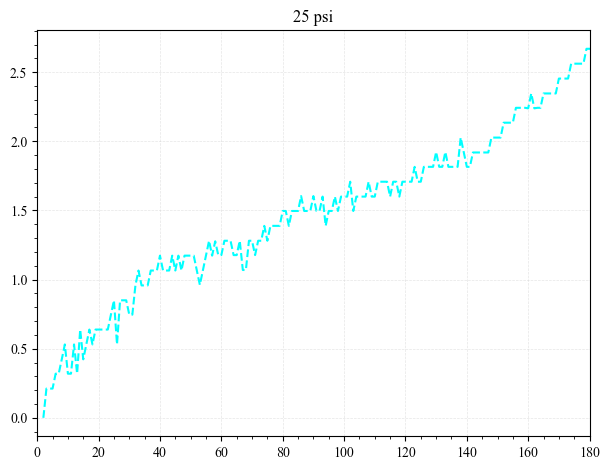

In [9]:
df5 = get_exp_peaks(33)
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax6 = ax
# ax6.plot(df5_v1["N"],df5_v1["dq"]/(0.5-0.24),color='black',linewidth=1.5)
ax6.plot(df5["N"],df5["dq"][0]/(0.5-0.24)-df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5,linestyle="--")
ax6.set_title('25 psi')
ax6.set_xlim([0,180])
# ax6.set_ylim([2,7])
fig.tight_layout()

In [10]:
sdfasdf

NameError: name 'sdfasdf' is not defined

In [ ]:

df3 = get_exp_peaks(31)
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax6 = ax
# ax6.plot(df3_v1["N"],df3_v1["dq"]/(0.5-0.24),color='black',linewidth=1.5)
ax6.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5,linestyle="--")
ax6.set_title('25 psi')
ax6.set_xlim([0,180])
# ax6.set_ylim([2,7])
fig.tight_layout()

: 

In [461]:
df5_v1 = get_exp_peaks_v1(35)
df3_v1 = get_exp_peaks_v1(31)

: 

In [15]:
df0 = get_exp_peaks(26)
df1 = get_exp_peaks(9)
df2 = get_exp_peaks(29)
df3 = get_exp_peaks(31)
df4 = get_exp_peaks(33)
df5 = get_exp_peaks(35)


: 

In [4]:
colors = ['blue','red','green','orange','magenta','cyan']

: 

In [ ]:

fig, ax = plt.subplots(3,2,figsize=(6.2,4.8*1.5))
ax1 = ax.flat[0]
ax1.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax1.set_title('0 psi')
ax2 = ax.flat[1]
ax2.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax2.set_title('5 psi')
ax3 = ax.flat[2]
ax3.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax3.set_title('10 psi')
ax4 = ax.flat[3]
ax4.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax4.set_title('15 psi')
ax5 = ax.flat[4]
ax5.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax5.set_title('20 psi')
ax6 = ax.flat[5]
ax6.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
ax6.set_title('25 psi')
fig.tight_layout()
fig.savefig(fig_DIR + "Cn_exp_individual_2.png")

: 

In [ ]:
colors = ['blue','red','green','orange','magenta','cyan']
fig, ax = plt.subplots(3,2,figsize=(6.2,4.8*1.5))
ax1 = ax.flat[0]
ax1.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax1.set_title('0 psi')
ax2 = ax.flat[1]
ax2.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax2.set_title('5 psi')
ax3 = ax.flat[2]
ax3.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax3.set_title('10 psi')
ax4 = ax.flat[3]
ax4.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax4.set_title('15 psi')
ax5 = ax.flat[4]
ax5.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax5.set_title('20 psi')
ax6 = ax.flat[5]
ax6.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
ax6.set_title('25 psi')
fig.tight_layout()
fig.savefig(fig_DIR + "Cn_exp_individual.png")

: 

In [ ]:
sdfsdf

: 

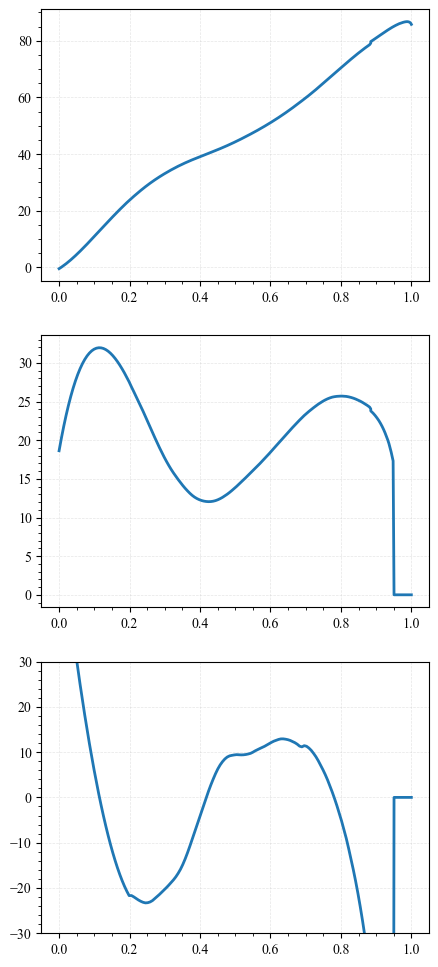

In [24]:
cell = 33
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
colors = ["tab:blue","tab:orange","tab:green","tab:red"]
n = 50
i=0
df = data[data["Cycle number"]==N1[n]]
df = df.dropna()
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
E = df["Expansion [mu m]"].to_numpy()
E = E-E[0]

idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
idx = idxi1[0]
t_ch = t[:idx-1]
I_ch = I[:idx-1]
V_ch = V[:idx-1]
Q_ch = Cap[:idx-1]
E_ch = E[:idx-1]
t_dh = t[idx+1:]-t[idx+1]
I_dh = I[idx+1:]
V_dh = V[idx+1:]
Q_dh = Cap[idx+1:]
E_dh = E[idx+1:]
window_length=61
polyorder=4
if len(t)>1000:
    window_length=501
S_ch = Q_ch/max(Q_ch)
Q_ch = np.flip(Q_ch)
S_ch = np.flip(S_ch)
E_ch = np.flip(E_ch)
dQ = savgol_filter(Q_ch,window_length,polyorder,1)
dE = savgol_filter(E_ch,window_length,polyorder,1)
Ef = savgol_filter(E_ch,window_length,polyorder,0)
dE2 = savgol_filter(E_ch,window_length,polyorder,2)
dE2 = dE2*(S_ch<=0.95)
dE = dE*(S_ch<=0.95)
dEdQ2 = dE2/dQ/dQ
dEdQ = dE/dQ
pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
pks = np.append(pks1,pks2)

p1s = np.round(S_ch[pks1[0]],4)
p2s = np.round(S_ch[pks2[0]],4)
p1q = np.round(Q_ch[pks1[0]],3)
p2q = np.round(Q_ch[pks2[0]],3)
Qmax = np.round(Q_ch[-1],3)
df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
df1["ds"] = df1["p2s"] - df1["p1s"]
df1["dq"] = df1["p2q"] - df1["p1q"]
dfa.append(df1)

# ax.plot(t_ch,E_ch)
fig,ax = plt.subplots(3,1,figsize=(5,12))   
ax1 = ax.flat[0]
ax1.plot(S_ch,Ef,label="_nolegend_",color=colors[i])
ax2 = ax.flat[1]
ax2.plot(S_ch,dEdQ,label="_nolegend_",color=colors[i])
ax3 = ax.flat[2]
ax3.plot(S_ch,dEdQ2,label="_nolegend_",color=colors[i])
ax3.set_ylim([-30,30])
# ax.plot(S_ch,Ef,"--",color=colors[i])

# ax.plot(S_ch,dEdQ2)
# ax.plot(S_ch[pks1[0]],dEdQ2[pks1[0]],'ko',label='_nolegend_')
# ax.plot(S_ch[pks2[0]],dEdQ2[pks2[0]],'ko',label='_nolegend_')
# ax.plot(S_ch[pks2],dEdQ2[pks2],'ko')
# ax.set_ylim([-40,40])
# ax.set_title("Cell:"+cell_no)
# ax.set_xlabel("SOC")
# ax.set_ylabel("Expansion 2nd derivative")
# ax.set_ylabel("Expansion filtered")
# fig.savefig(fig_DIR + "exp_derivatives_cell"+cell_no+".png")
fig.savefig(fig_DIR + "exp_allder_cell"+cell_no+".png")
# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])

In [20]:
len(Ef)

238

In [ ]:
cell = 35
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
fig,ax = plt.subplots(1,1)   
cycles = range(1,150,40)
colors = ["tab:blue","tab:orange","tab:green","tab:red"]
i=0
for n in cycles:
    df = data[data["Cycle number"]==N1[n]]
    df = df.dropna()
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    E = df["Expansion [mu m]"].to_numpy()
    E = E-E[0]

    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    E_ch = E[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    E_dh = E[idx+1:]
    window_length=81
    polyorder=2
    if len(t)>1000:
        window_length=501
    S_ch = Q_ch/max(Q_ch)
    Q_ch = np.flip(Q_ch)
    S_ch = np.flip(S_ch)
    E_ch = np.flip(E_ch)
    dQ = savgol_filter(Q_ch,window_length,polyorder,1)
    Ef = savgol_filter(E_ch,window_length,polyorder,0)
    dE2 = savgol_filter(E_ch,window_length,polyorder,2)
    dE2 = dE2*(S_ch<=0.95)
    dEdQ2 = dE2/dQ/dQ
    pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
    pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
    pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    pks = np.append(pks1,pks2)

    p1s = np.round(S_ch[pks1[0]],4)
    p2s = np.round(S_ch[pks2[0]],4)
    p1q = np.round(Q_ch[pks1[0]],3)
    p2q = np.round(Q_ch[pks2[0]],3)
    Qmax = np.round(Q_ch[-1],3)
    df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
    df1["ds"] = df1["p2s"] - df1["p1s"]
    df1["dq"] = df1["p2q"] - df1["p1q"]
    dfa.append(df1)

# ax.plot(t_ch,E_ch)
    ax.plot(S_ch,E_ch,label="_nolegend_",color=colors[i])
    ax.plot(S_ch,Ef,"--",color=colors[i])
    
    # ax.plot(S_ch,dEdQ2)
    # ax.plot(S_ch[pks1[0]],dEdQ2[pks1[0]],'ko',label='_nolegend_')
    # ax.plot(S_ch[pks2[0]],dEdQ2[pks2[0]],'ko',label='_nolegend_')
    # ax.plot(S_ch[pks2],dEdQ2[pks2],'ko')
    # ax.set_ylim([-40,40])
    i+=1
ax.legend(cycles)
ax.set_title("Cell:"+cell_no)
ax.set_xlabel("SOC")
ax.set_ylabel("Expansion 2nd derivative")
ax.set_ylabel("Expansion filtered")
# fig.savefig(fig_DIR + "exp_derivatives_cell"+cell_no+".png")
fig.savefig(fig_DIR + "exp_filtered_cell"+cell_no+".png")
# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])

: 

In [ ]:
cell = 35
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
fig,ax = plt.subplots(1,1)   
cycles = range(1,150,40)
colors = ["tab:blue","tab:orange","tab:green","tab:red"]
i=0
for n in cycles:
    df = data[data["Cycle number"]==N1[n]]
    df = df.dropna()
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    E = df["Expansion [mu m]"].to_numpy()
    E = E-E[0]

    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    E_ch = E[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    E_dh = E[idx+1:]
    window_length=61
    polyorder=3
    if len(t)>1000:
        window_length=501
    S_ch = Q_ch/max(Q_ch)
    Q_ch = np.flip(Q_ch)
    S_ch = np.flip(S_ch)
    E_ch = np.flip(E_ch)
    dQ = savgol_filter(Q_ch,window_length,polyorder,1)
    Ef = savgol_filter(E_ch,window_length,polyorder,0)
    dE2 = savgol_filter(E_ch,window_length,polyorder,2)
    dE2 = dE2*(S_ch<=0.95)
    dEdQ2 = dE2/dQ/dQ
    pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
    pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
    pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    pks = np.append(pks1,pks2)

    p1s = np.round(S_ch[pks1[0]],4)
    p2s = np.round(S_ch[pks2[0]],4)
    p1q = np.round(Q_ch[pks1[0]],3)
    p2q = np.round(Q_ch[pks2[0]],3)
    Qmax = np.round(Q_ch[-1],3)
    df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
    df1["ds"] = df1["p2s"] - df1["p1s"]
    df1["dq"] = df1["p2q"] - df1["p1q"]
    dfa.append(df1)

# ax.plot(t_ch,E_ch)
    # ax.plot(S_ch,E_ch,label="_nolegend_",color=colors[i])
    # ax.plot(S_ch,Ef,"--",color=colors[i])
    
    ax.plot(S_ch,dEdQ2)
    ax.plot(S_ch[pks1[0]],dEdQ2[pks1[0]],'ko',label='_nolegend_')
    ax.plot(S_ch[pks2[0]],dEdQ2[pks2[0]],'ko',label='_nolegend_')
    # ax.plot(S_ch[pks2],dEdQ2[pks2],'ko')
    ax.set_ylim([-40,40])
    i+=1
ax.legend(cycles)
ax.set_title("Cell:"+cell_no)
ax.set_xlabel("SOC")
ax.set_ylabel("Expansion 2nd derivative")
fig.savefig(fig_DIR + "exp_derivatives_cell"+cell_no+".png")

# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])

: 

In [ ]:
cell = 35
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
fig,ax = plt.subplots(1,1)   
cycles = range(1,150,40)
for n in cycles:
    df = data[data["Cycle number"]==N1[n]]
    df = df.dropna()
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    E = df["Expansion [mu m]"].to_numpy()
    E = E-E[0]

    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    E_ch = E[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    E_dh = E[idx+1:]
    window_length=101
    polyorder=5
    if len(t)>1000:
        window_length=501
    S_ch = Q_ch/max(Q_ch)
    dQ = savgol_filter(Q_ch,window_length,polyorder,1)
    dE2 = savgol_filter(E_ch,window_length,polyorder,2)
    dE2 = dE2*(S_ch<=0.95)
    dEdQ2 = dE2/dQ/dQ
    pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
    pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
    pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    pks = np.append(pks1,pks2)

    p1s = np.round(S_ch[pks1[0]],4)
    p2s = np.round(S_ch[pks2[0]],4)
    p1q = np.round(Q_ch[pks1[0]],3)
    p2q = np.round(Q_ch[pks2[0]],3)
    Qmax = np.round(Q_ch[-1],3)
    df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
    df1["ds"] = df1["p2s"] - df1["p1s"]
    df1["dq"] = df1["p2q"] - df1["p1q"]
    dfa.append(df1)

# ax.plot(t_ch,E_ch)
    ax.plot(Q_ch,dEdQ2)
    ax.plot(Q_ch[pks1[0]],dEdQ2[pks1[0]],'ko',label='_nolegend_')
    ax.plot(Q_ch[pks2[0]],dEdQ2[pks2[0]],'ko',label='_nolegend_')
    # ax.plot(S_ch[pks2],dEdQ2[pks2],'ko')
    ax.set_ylim([-40,40])
ax.legend(cycles)
ax.set_title("Cell:"+cell_no)
ax.set_xlabel("Charge Capacity [Ah]")
ax.set_ylabel("Expansion 2nd derivative")
df2 = pd.concat(dfa)
fig.savefig(fig_DIR + "exp_derivatives_q_cell"+cell_no+".png")
# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])

: 

In [ ]:
dEdQ2[31]

: 

In [ ]:
cell = 35
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
dfa = []
fig,ax = plt.subplots(1,1)   
n1 = 55
cycles = range(n1,n1+5,1)
for n in cycles:
    df = data[data["Cycle number"]==N1[n]]
    df = df.dropna()
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    E = df["Expansion [mu m]"].to_numpy()
    E = E-E[0]

    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    E_ch = E[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    E_dh = E[idx+1:]
    window_length=61
    polyorder=4
    if len(t)>1000:
        window_length=501
    S_ch = Q_ch/max(Q_ch)
    dQ = savgol_filter(Q_ch,window_length,polyorder,1)
    dE2 = savgol_filter(E_ch,window_length,polyorder,2)
    dE3 = savgol_filter(E_ch,window_length,polyorder,3)
    dE2 = dE2*(S_ch<=0.95)
    dEdQ2 = dE2/dQ/dQ
    dEdQ3 = dE3/dQ/dQ/dQ
    Qmax = np.round(Q_ch[-1],3)
    # pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
    # pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    # pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
    # pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    # pks = np.append(pks1,pks2)

    Q_chi = np.arange(0,Q_ch[-1],0.0001)
    S_chi = Q_chi/max(Q_chi)

    # int_dEdQ2 = interpolate.interp1d(Q_ch,dEdQ2, fill_value="extrapolate")
    # dEdQ2i = int_dEdQ2(Q_chi)
    # pks_,_ = find_peaks(-dEdQ2i,height=0.01,width=0.1)
    # pks1 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
    # pks_,_ = find_peaks(dEdQ2i,height=0.01,width=0.1)
    # pks2 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]


    int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=True)
    dEdQ3i = int_dEdQ3(Q_chi)
    zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
    zc = zc[0:2]

    int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=False)
    dEdQ3i = int_dEdQ3(Q_chi)
    zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
    zc = zc[1:3]
    # ax.plot(t_ch,E_ch)
    # ax.plot(Q_ch,dEdQ2)
    # ax.plot(Q_ch[pks1[0]],dEdQ2[pks1[0]],'ko',label='_nolegend_')
    # ax.plot(Q_ch[pks2[0]],dEdQ2[pks2[0]],'ko',label='_nolegend_')
    # ax.plot(Q_chi,dEdQ2i)
    # ax.plot(Q_chi[pks1[0]],dEdQ2i[pks1[0]],'ko',label='_nolegend_')
    # ax.plot(Q_chi[pks2[0]],dEdQ2i[pks2[0]],'ko',label='_nolegend_')
    ax.plot(Q_ch,dEdQ3)
    ax.plot(Q_chi[zc],dEdQ3i[zc],'ko',label="_nolegend_")fuzz
    # ax.plot(S_ch[pks2],dEdQ2[pks2],'ko')
    ax.set_ylim([-40,40])
    dfa.append(df1)
ax.legend(cycles)
ax.set_title("Cell:"+cell_no)
ax.set_xlabel("Charge Capacity [Ah]")
ax.set_ylabel("Expansion 4th derivative")
df2 = pd.concat(dfa)
fig.savefig(fig_DIR + "exp_derivatives_q_local_cell_"+cell_no+"window_"+str(window_length)+".png")
# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])

: 

In [ ]:
Q_chi[zc]

: 

In [ ]:
df2['Cn'] = (df2["p2q"]-df2["p1q"])/(0.5-0.24)
df2

: 

In [ ]:
df

: 

In [ ]:
cell = 33
n = 120
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
fig,ax = plt.subplots(1,1)
for n in range(1,150,30):
    df = data[data["Cycle number"]==N1[n]]
    df = df.dropna()
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    E = df["Expansion [mu m]"].to_numpy()
    E = E-E[0]
    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    E_ch = E[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    E_dh = E[idx+1:]

    window_length=31
    polyorder=3
    S_ch = Q_ch/max(Q_ch)
    dQ = savgol_filter(Q_ch,window_length,polyorder,1)
    dE2 = savgol_filter(E_ch,window_length,polyorder,2)
    dE2 = dE2*(S_ch<=0.95)
    dEdQ2 = dE2/dQ/dQ
    pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
    pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
    pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    pks = np.append(pks1,pks2)

    p1s = np.round(S_ch[pks1],4)
    p2s = np.round(S_ch[pks2],4)
    p1q = np.round(Q_ch[pks1],3)
    p2q = np.round(Q_ch[pks2],3)
    Qmax = np.round(Q_ch[-1],3)
    
# ax.plot(t_ch,E_ch)
    ax.plot(S_ch,dEdQ2)
    ax.set_ylim([-40,40])
ax.legend(range(1,150,30))
# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])

: 

In [ ]:
cell = 28
n = 16
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
# print(N1[-1])
df = data[data["Cycle number"]==N1[n]]
df = df.dropna()
df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
t = df["Time [s]"].to_numpy()
I = df["Current [mA]"].to_numpy()/1000
V = df["Voltage [V]"].to_numpy()
Q = df["Q [Ah]"].to_numpy()
Cap = df["Capacity [Ah]"].to_numpy()
E = df["Expansion [mu m]"].to_numpy()
E = E-E[0]
idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
idx = idxi1[0]
t_ch = t[:idx-1]
I_ch = I[:idx-1]
V_ch = V[:idx-1]
Q_ch = Cap[:idx-1]
E_ch = E[:idx-1]
t_dh = t[idx+1:]-t[idx+1]
I_dh = I[idx+1:]
V_dh = V[idx+1:]
Q_dh = Cap[idx+1:]
E_dh = E[idx+1:]

window_length=51
polyorder=3
S_ch = Q_ch/max(Q_ch)
dQ = savgol_filter(Q_ch,window_length,polyorder,1)
dE2 = savgol_filter(E_ch,window_length,polyorder,2)
dE2 = dE2*(S_ch<=0.95)
dEdQ2 = dE2/dQ/dQ
pks_,_ = find_peaks(-dEdQ2,prominence=0.1)
pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
pks_,_ = find_peaks(dEdQ2,prominence=0.1)
pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
pks = np.append(pks1,pks2)

p1s = np.round(S_ch[pks1],4)
p2s = np.round(S_ch[pks2],4)
p1q = np.round(Q_ch[pks1],3)
p2q = np.round(Q_ch[pks2],3)
Qmax = np.round(Q_ch[-1],3)

fig,ax = plt.subplots(1,1,figsize=(5,4))
# ax1 = ax.flat[0]
# ax1.plot(t,E)
# ax2 = ax.flat[1]
# ax2.plot(t,I)
ax.plot(Q_ch,dEdQ2)
ax.plot(Q_ch[pks1],dEdQ2[pks1],'ro',markersize=10)
ax.plot(Q_ch[pks2],dEdQ2[pks2],'ro',markersize=10)
ax.text(1.8,-20,r"$x_{p1}=0.24$",fontsize=15)
ax.text(3,15,r"$x_{p2}=0.5$",fontsize=15)
# ax.set_xlim([0.1,0.9])
ax.set_ylim([-25,+25])
ax.set_title(r"2nd Derivative of Expansion wrt Q: $\frac{d^2t}{dQ^2}$")
ax.set_xlabel("Q [Ah]")
ax.set_ylabel(r"$\frac{d^2t}{dQ^2}$")
fig.savefig(fig_DIR + f"Model_Expansion_data.png")
# df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])

: 

In [ ]:
cvbvc

: 

In [ ]:
window_length=51
polyorder=3
dQ = savgol_filter(Q_ch,window_length,polyorder,1)
dV = savgol_filter(V_ch,window_length,polyorder,1)
dVdQ = dV/dQ
fig,ax = plt.subplots(1,1)
ax.plot(Q_ch/max(Q_ch),dVdQ)
ax.set_xlim([0.1,0.9])
ax.set_ylim([0,0.6])

: 

In [ ]:
def graphite_volume_change(sto):
    stoichpoints = np.array([0,0.12,0.18,0.24,0.50,1])
    thicknesspoints = np.array([0,2.406/100,3.3568/100,4.3668/100,5.583/100,13.0635/100])
    x = [sto]
    t_change = pybamm.Interpolant(stoichpoints, thicknesspoints, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    t_change = np.interp(x,stoichpoints,thicknesspoints)
    return t_change

: 

In [ ]:
xa = np.arange(0,1,0.001)
En = []
for x in xa:
    En.append(graphite_volume_change(x))
En = np.concatenate(En)

: 

In [ ]:
window_length=271
polyorder=3
dQ = savgol_filter(xa,window_length,polyorder,1)
dE2 = savgol_filter(En,window_length,polyorder,2)
dEdQ2 = dE2/dQ/dQ

: 

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(7,8))
ax1 = ax.flat[0]
ax1.plot(xa,En)
ax1.set_title("Volumetric Strain")
ax2 = ax.flat[1]
ax2.plot(xa,dEdQ2)
ax2.set_title("2nd Diff Volumetric Strain")
ax2.axvline(x=0.24,color='r', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2)
ax2.axvline(x=0.50,color='r', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2)
ax1.text(0.25,0.08,r"$x_{p1}=0.24$")
ax1.text(0.51,0.08,r"$x_{p2}=0.5$")
ax2.text(0.25,0,r"$x_{p1}=0.24$")
ax2.text(0.51,0,r"$x_{p2}=0.5$")
ax2.set_xlabel("Stoichiometry")
fig.savefig(fig_DIR + f"Model_Expansion.png")

: 

In [ ]:
def graphite_ocp_PeymanMPM(sto):
    u_eq = (
        0.063
        + 0.8 * math.exp(-75 * (sto + 0.007))
        - 0.0120 * math.tanh((sto - 0.127) / 0.016)
        - 0.0118 * math.tanh((sto - 0.155) / 0.016)
        - 0.0035 * math.tanh((sto - 0.220) / 0.020)
        - 0.0095 * math.tanh((sto - 0.190) / 0.013)
        - 0.0145 * math.tanh((sto - 0.490) / 0.020)
        - 0.0800 * math.tanh((sto - 1.030) / 0.055)
    )

    return u_eq

def NMC_ocp_PeymanMPM(sto):
    u_eq = (
        4.3452
        - 1.6518 * sto
        + 1.6225 * (sto ** 2)
        - 2.0843 * (sto ** 3)
        + 3.5146 * (sto ** 4)
        - 2.2166 * (sto ** 5)
        - 0.5623 * math.exp(109.451 * sto - 100.006)
    )

    return u_eq

: 

In [ ]:
window_length=271
polyorder=3
dQ = savgol_filter(xa,window_length,polyorder,1)
dV = savgol_filter(En,window_length,polyorder,1)
dVdQ = dV/dQ

: 

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(7,8))
ax1 = ax.flat[0]
ax1.plot(xa,En)
ax1.set_title("Open Circuit Potential")
ax2 = ax.flat[1]
ax2.plot(xa,dEdQ2)
ax2.set_title("2nd Diff Volumetric Strain")
ax2.axvline(x=0.24,color='r', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2)
ax2.axvline(x=0.50,color='r', linestyle='--',linewidth=1,clip_on=False,ymin=0,ymax=2)
ax1.text(0.25,0.08,r"$x_{p1}=0.24$")
ax1.text(0.51,0.08,r"$x_{p2}=0.5$")
ax2.text(0.25,0,r"$x_{p1}=0.24$")
ax2.text(0.51,0,r"$x_{p2}=0.5$")
ax2.set_xlabel("Stoichiometry")
fig.savefig(fig_DIR + f"Model_Voltage.png")

: 